In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## Data Collection

In [2]:
df = pd.read_csv("Quality_of_Life.csv")

df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,'Very Low',7.8,'Low',56.17,'Very High',84.44,'Very High',0.0,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',0.0,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',': 104.16','Low'
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,NaN,0.0,NaN,5.00,'Very Low',1.72,'Very Low',0.0,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.7,'Very High',45.09,'High',63.87,'High',': 98.83','Very Low'


In [3]:
## View Dataset

In [4]:
df.shape

(236, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          190 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    234 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               221 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   114 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            191 non-null    object 
 11  Property Price to Income Value     236 non-null    object 

In [6]:

df.describe()

,Purchasing Power Value,Safety Value,Health Care Value,Climate Value,Cost of Living Value,Traffic Commute Time Value,Pollution Value
count,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000
mean,55.573305,55.274449,54.731568,37.598178,37.526314,28.492966,54.266186
std,52.008245,16.914298,20.607381,40.851542,26.026565,17.347242,25.853695
min,0.000000,0.000000,0.000000,-3.540000,0.000000,0.000000,0.000000
25%,16.340000,43.857500,45.807500,0.000000,24.550000,17.100000,35.700000
50%,42.930000,54.635000,57.150000,0.000000,36.895000,29.845000,59.765000
75%,85.940000,68.132500,68.447500,79.332500,51.090000,38.870000,73.740000
max,281.830000,100.000000,100.000000,99.890000,137.370000,100.000000,106.900000


###  Data Cleaning & Preprocessing

In [7]:
## Check Missing Values

In [8]:
df.isnull().sum()

country                                0
Purchasing Power Value                 0
Purchasing Power Category             46
Safety Value                           0
Safety Category                        2
Health Care Value                      0
Health Care Category                  15
Climate Value                          0
Climate Category                     122
Cost of Living Value                   0
Cost of Living Category               45
Property Price to Income Value         0
Property Price to Income Category     21
Traffic Commute Time Value             0
Traffic Commute Time Category         29
Pollution Value                        0
Pollution Category                    10
Quality of Life Value                  0
Quality of Life Category             122
dtype: int64

In [9]:
 ## replace the missing values with "Unknown".

In [10]:
category_cols = [col for col in df.columns if "Category" in col]

df[category_cols] = df[category_cols].fillna("Unknown")

In [11]:
## verify:

In [12]:
df[category_cols].isnull().sum()

Purchasing Power Category            0
Safety Category                      0
Health Care Category                 0
Climate Category                     0
Cost of Living Category              0
Property Price to Income Category    0
Traffic Commute Time Category        0
Pollution Category                   0
Quality of Life Category             0
dtype: int64

In [13]:
## Check for duplicate rows

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
df = df.drop_duplicates()

In [16]:
## Verify data types

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          236 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    236 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               236 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   236 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            236 non-null    object 
 11  Property Price to Income Value     236 non-null    object 

In [18]:
## check column if it hasn't already been converted.

In [19]:
df["Property Price to Income Value"] = pd.to_numeric(
    df["Property Price to Income Value"],
    errors="coerce"
)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          236 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    236 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               236 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   236 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            236 non-null    object 
 11  Property Price to Income Value     233 non-null    float64

In [21]:
df["Property Price to Income Value"].unique()[:20]

array([ 7.8 ,  5.33, 14.88,  0.  , 21.7 ,  9.03,  8.01,  1.84, 20.05,
       20.95,  5.32,  8.25, 11.76, 15.24,  4.9 , 12.26, 14.67, 12.79,
        6.82,  6.06])

In [22]:
## Remove Quotes from Category Columns

In [23]:
category_cols = [col for col in df.columns if "Category" in col]

for col in category_cols:
    df[col] = df[col].astype(str).str.replace("'", "", regex=False)

In [24]:
## Drop the category columns before building your machine learning model:

In [25]:
category_cols = [col for col in df.columns if "Category" in col]

df_ml = df.drop(columns=category_cols)

In [26]:
df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,0.00,Unknown,21.08,Very Low,7.80,Low,56.17,Very High,84.44,Very High,0.0,Unknown
1,Aland Islands,125.01,Very High,71.81,High,79.72,High,0.00,Unknown,53.44,Low,5.33,Low,19.05,Very Low,18.05,Very Low,0.0,Unknown
2,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,Low,14.88,High,36.74,Moderate,77.25,High,': 104.16',Low
3,Alderney,0.00,Unknown,83.79,Very High,100.00,Very High,0.00,Unknown,0.00,Unknown,0.00,Unknown,5.00,Very Low,1.72,Very Low,0.0,Unknown
4,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,Very Low,21.70,Very High,45.09,High,63.87,High,': 98.83',Very Low


In [27]:
## Clean Quality of Life Values

## Your Quality of Life column contains values like

In [28]:
df["Quality of Life Value"] = (
    df["Quality of Life Value"]
    .astype(str)
    .str.replace(":", "")
    .str.replace("'", "")
    .str.strip()
)

df["Quality of Life Value"] = pd.to_numeric(
    df["Quality of Life Value"],
    errors="coerce"
)

In [29]:
## Replace Zero Values with NaN

In [30]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].replace(0, np.nan)

In [31]:
## Fill Missing Values

In [32]:
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

### Exploratory Data Analysis (EDA)

In [33]:
## Business Question: What does the dataset look like? Display the First Five Rows

In [34]:
df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,80.60,Unknown,21.08,Very Low,7.80,Low,56.17,Very High,84.44,Very High,130.42,Unknown
1,Aland Islands,125.01,Very High,71.81,High,79.72,High,80.60,Unknown,53.44,Low,5.33,Low,19.05,Very Low,18.05,Very Low,130.42,Unknown
2,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,Low,14.88,High,36.74,Moderate,77.25,High,104.16,Low
3,Alderney,52.70,Unknown,83.79,Very High,100.00,Very High,80.60,Unknown,41.72,Unknown,12.41,Unknown,5.00,Very Low,1.72,Very Low,130.42,Unknown
4,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,Very Low,21.70,Very High,45.09,High,63.87,High,98.83,Very Low


In [35]:
df.tail()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
231,Wallis And Futuna,52.70,Unknown,54.745,Unknown,58.15,Unknown,80.60,Unknown,41.72,Unknown,12.41,Unknown,32.86,Unknown,60.78,Unknown,130.42,Unknown
232,Western Sahara,52.70,Unknown,62.870,High,58.15,Unknown,80.60,Unknown,41.72,Unknown,12.75,High,32.86,Unknown,60.78,Unknown,130.42,Unknown
233,Yemen,20.74,Very Low,34.070,Low,25.31,Low,80.60,Unknown,48.66,Low,15.98,High,15.00,Very Low,83.17,Very High,130.42,Unknown
234,Zambia,22.32,Very Low,54.390,Moderate,54.44,Moderate,80.60,Unknown,36.74,Very Low,72.42,Very High,38.86,Moderate,80.90,Very High,130.42,Unknown
235,Zimbabwe,28.76,Very Low,39.310,Low,44.80,Moderate,96.76,Very High,35.36,Very Low,17.35,Very High,27.79,Low,78.53,High,94.20,Very Low


Dataset Shape

Business Question: How many countries and variables are included?

In [36]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 236
Columns: 19


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          236 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    236 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               236 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   236 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            236 non-null    object 
 11  Property Price to Income Value     236 non-null    float64

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Purchasing Power Value,236.0,65.845339,44.676320,2.55,36.7000,52.700,85.9400,281.83
Safety Value,236.0,55.738390,16.120715,15.89,44.2375,54.745,68.1325,100.00
Health Care Value,236.0,58.427542,14.848796,18.52,49.1325,58.150,68.4475,100.00
Climate Value,236.0,79.264280,12.308687,-3.54,80.6000,80.600,80.6000,99.89
Cost of Living Value,236.0,45.481398,18.642349,17.90,34.6450,41.720,51.0900,137.37
Property Price to Income Value,236.0,23.328390,51.556796,0.55,8.1350,12.410,17.3850,450.40
Traffic Commute Time Value,236.0,33.227034,12.795320,2.95,27.0300,32.860,38.8700,100.00
Pollution Value,236.0,57.099153,22.901903,1.72,40.0900,60.780,73.7400,106.90
Quality of Life Value,236.0,132.545169,28.700765,17.47,130.4200,130.420,130.4200,224.31


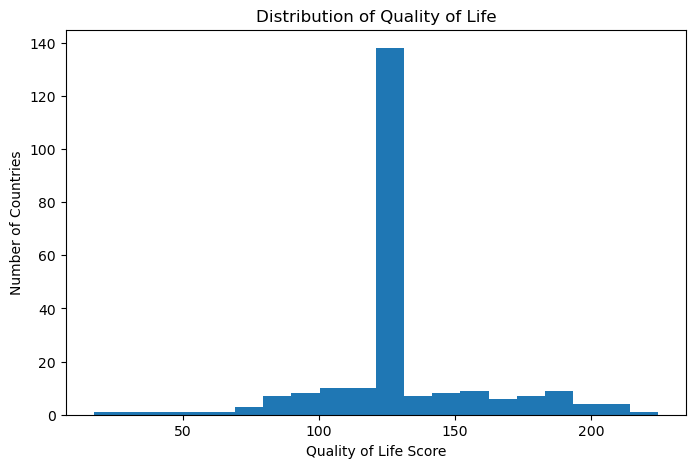

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Quality of Life Value"], bins=20)

plt.title("Distribution of Quality of Life")

plt.xlabel("Quality of Life Score")

plt.ylabel("Number of Countries")

plt.show()

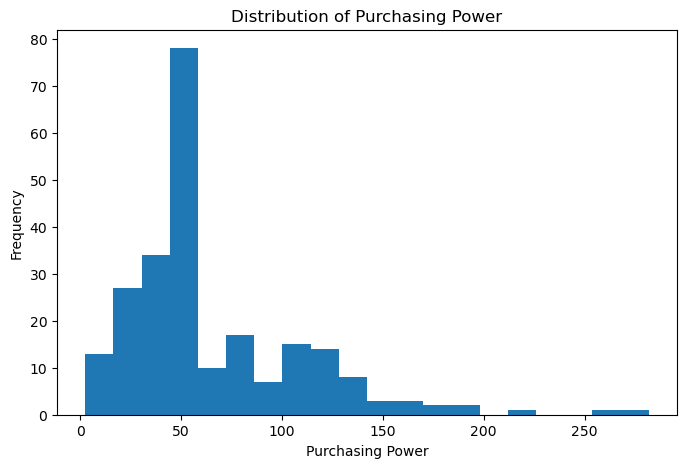

In [40]:
plt.figure(figsize=(8,5))

plt.hist(df["Purchasing Power Value"], bins=20)

plt.title("Distribution of Purchasing Power")

plt.xlabel("Purchasing Power")

plt.ylabel("Frequency")

plt.show()

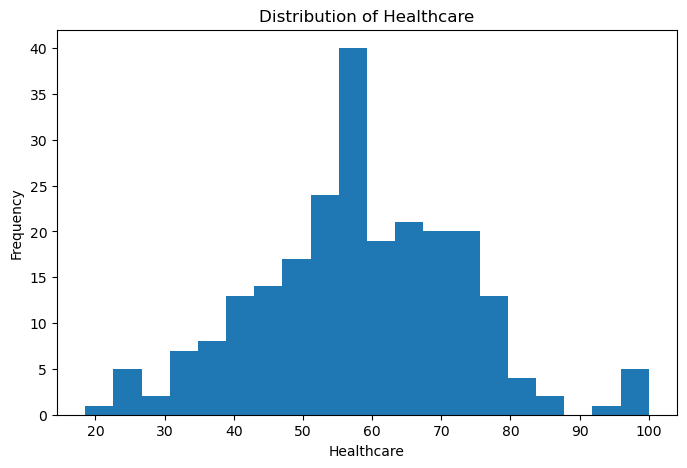

In [41]:
plt.figure(figsize=(8,5))

plt.hist(df["Health Care Value"], bins=20)

plt.title("Distribution of Healthcare")

plt.xlabel("Healthcare")

plt.ylabel("Frequency")

plt.show()

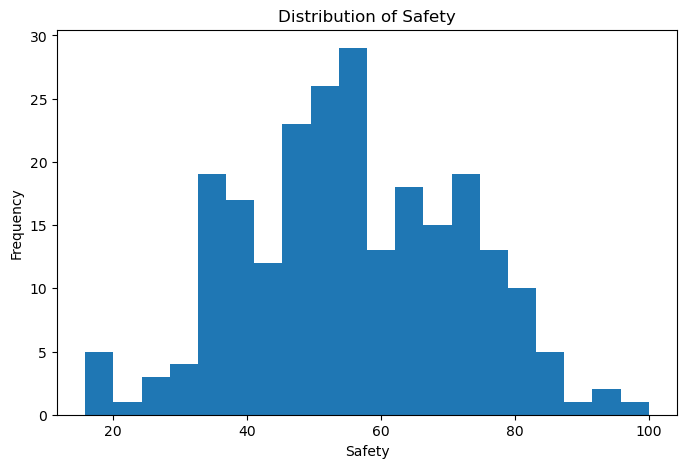

In [42]:
plt.figure(figsize=(8,5))

plt.hist(df["Safety Value"], bins=20)

plt.title("Distribution of Safety")

plt.xlabel("Safety")

plt.ylabel("Frequency")

plt.show()

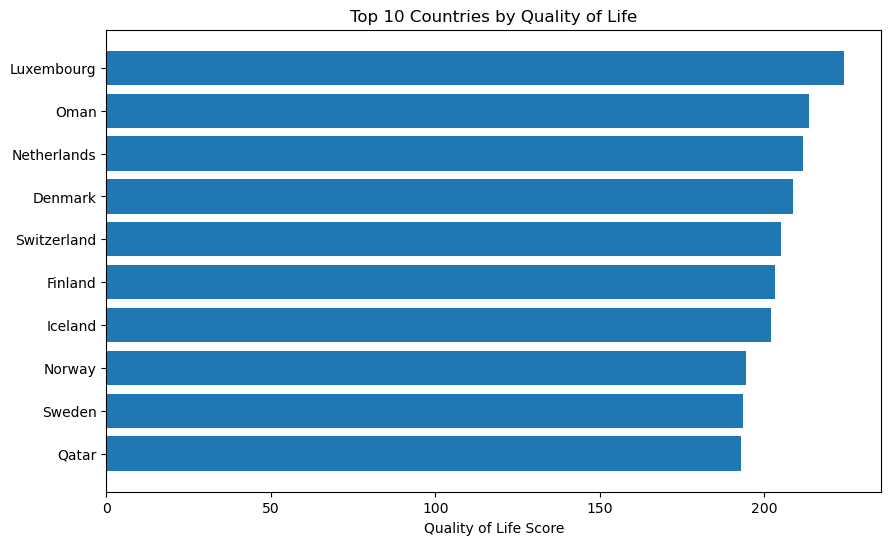

         country  Quality of Life Value
123   Luxembourg                 224.31
159         Oman                 213.42
148  Netherlands                 211.85
55       Denmark                 208.65
204  Switzerland                 204.91
70       Finland                 203.06
95       Iceland                 202.04
158       Norway                 194.48
203       Sweden                 193.48
171        Qatar                 192.73


In [43]:
top10 = df.nlargest(10, "Quality of Life Value")

plt.figure(figsize=(10,6))

plt.barh(
    top10["country"],
    top10["Quality of Life Value"]
)

plt.title("Top 10 Countries by Quality of Life")

plt.xlabel("Quality of Life Score")

plt.gca().invert_yaxis()

plt.show()

print(top10[["country","Quality of Life Value"]])

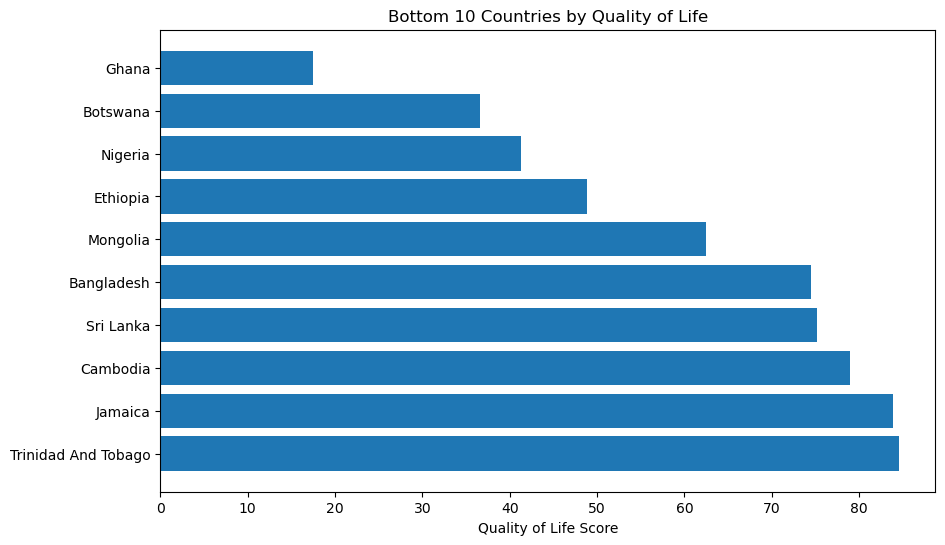

                 country  Quality of Life Value
79                 Ghana                  17.47
29              Botswana                  36.55
153              Nigeria                  41.24
66              Ethiopia                  48.88
139             Mongolia                  62.52
18            Bangladesh                  74.51
200            Sri Lanka                  75.17
36              Cambodia                  78.92
105              Jamaica                  83.92
213  Trinidad And Tobago                  84.52


In [44]:
bottom10 = df.nsmallest(10,"Quality of Life Value")

plt.figure(figsize=(10,6))

plt.barh(
    bottom10["country"],
    bottom10["Quality of Life Value"]
)

plt.title("Bottom 10 Countries by Quality of Life")

plt.xlabel("Quality of Life Score")

plt.gca().invert_yaxis()

plt.show()

print(bottom10[["country","Quality of Life Value"]])

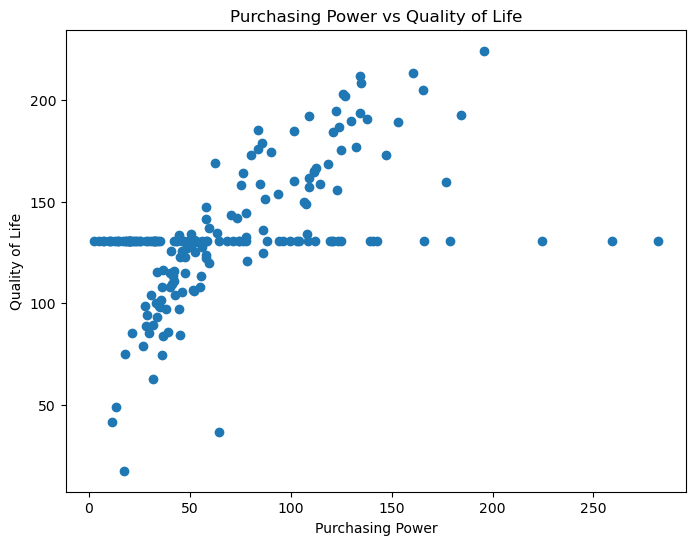

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Purchasing Power Value"],
    df["Quality of Life Value"]
)

plt.xlabel("Purchasing Power")

plt.ylabel("Quality of Life")

plt.title("Purchasing Power vs Quality of Life")

plt.show()

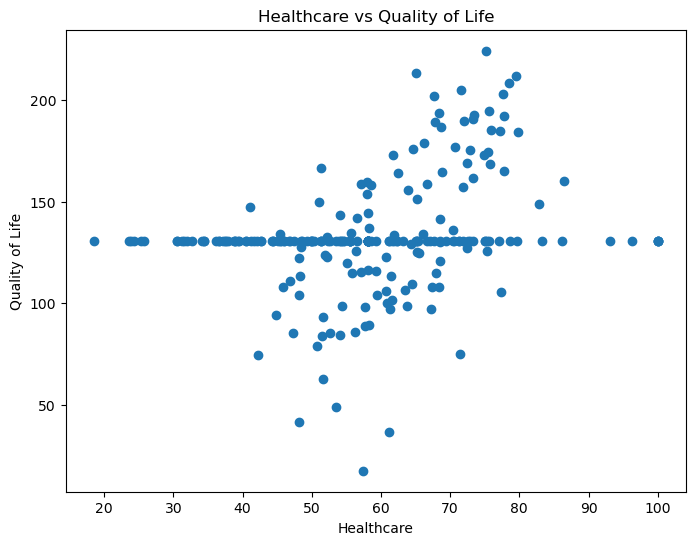

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Health Care Value"],
    df["Quality of Life Value"]
)

plt.xlabel("Healthcare")

plt.ylabel("Quality of Life")

plt.title("Healthcare vs Quality of Life")

plt.show()

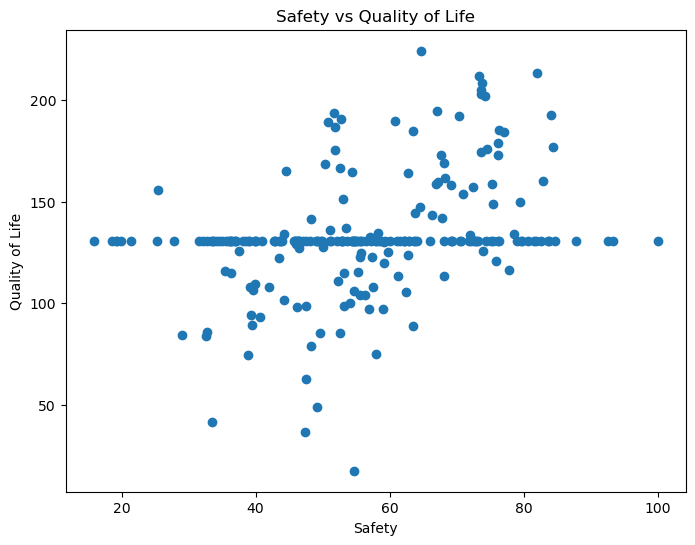

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Safety Value"],
    df["Quality of Life Value"]
)

plt.xlabel("Safety")

plt.ylabel("Quality of Life")

plt.title("Safety vs Quality of Life")

plt.show()

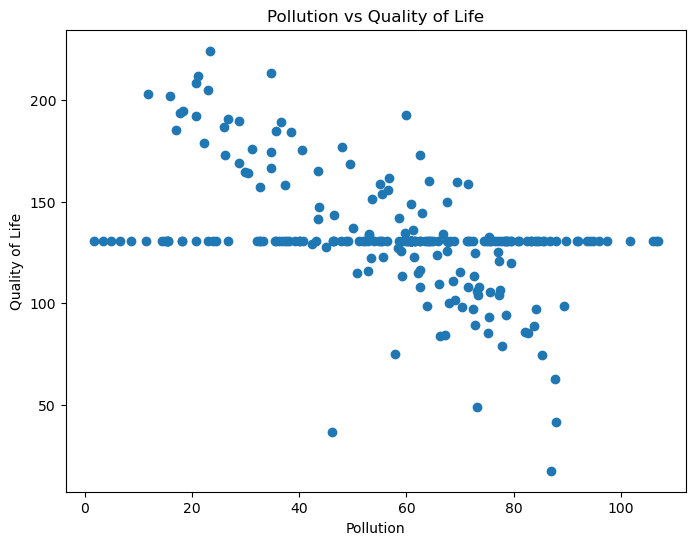

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Pollution Value"],
    df["Quality of Life Value"]
)

plt.xlabel("Pollution")

plt.ylabel("Quality of Life")

plt.title("Pollution vs Quality of Life")

plt.show()

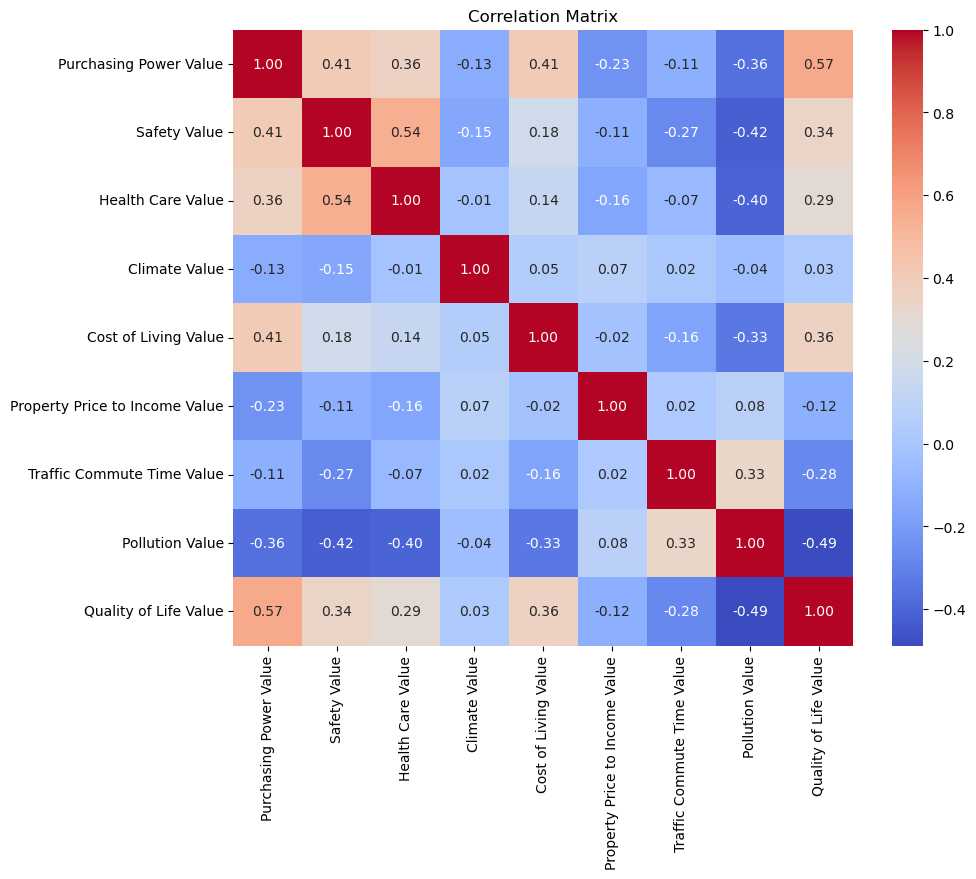

In [49]:
import seaborn as sns

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [50]:
quality_corr = (
    corr["Quality of Life Value"]
    .sort_values(ascending=False)
)

print(quality_corr)

Quality of Life Value             1.000000
Purchasing Power Value            0.569030
Cost of Living Value              0.362809
Safety Value                      0.340216
Health Care Value                 0.292982
Climate Value                     0.028355
Property Price to Income Value   -0.120441
Traffic Commute Time Value       -0.277431
Pollution Value                  -0.487968
Name: Quality of Life Value, dtype: float64


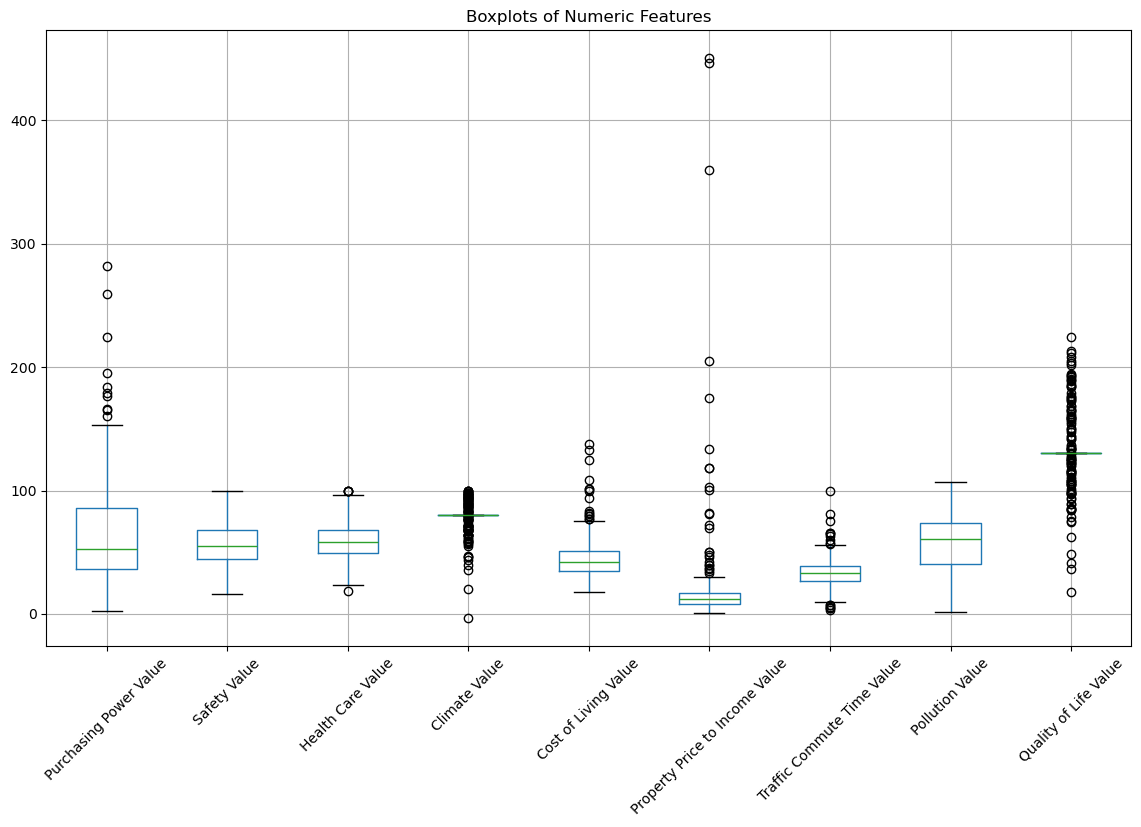

In [51]:
numeric_columns = [
    "Purchasing Power Value",
    "Safety Value",
    "Health Care Value",
    "Climate Value",
    "Cost of Living Value",
    "Property Price to Income Value",
    "Traffic Commute Time Value",
    "Pollution Value",
    "Quality of Life Value"
]

plt.figure(figsize=(14,8))

df[numeric_columns].boxplot(rot=45)

plt.title("Boxplots of Numeric Features")

plt.show()

In [52]:
df["Quality of Life Category"].value_counts()

Quality of Life Category
Unknown      122
Very High     33
Very Low      26
Moderate      25
Low           19
High          11
Name: count, dtype: int64

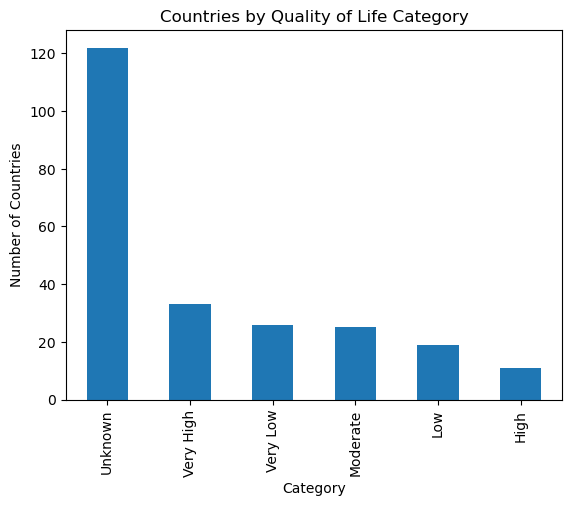

In [53]:
df["Quality of Life Category"].value_counts().plot(
    kind="bar"
)

plt.title("Countries by Quality of Life Category")

plt.xlabel("Category")

plt.ylabel("Number of Countries")

plt.show()

In [54]:
# Features (Independent Variables)
X = df[
    [
        "Purchasing Power Value",
        "Safety Value",
        "Health Care Value",
        "Climate Value",
        "Cost of Living Value",
        "Property Price to Income Value",
        "Traffic Commute Time Value",
        "Pollution Value"
    ]
]

# Target (Dependent Variable)
y = df["Quality of Life Value"]

print(X.head())
print(y.head())

   Purchasing Power Value  Safety Value  Health Care Value  Climate Value  \
0                   32.15         25.33              24.24          80.60   
1                  125.01         71.81              79.72          80.60   
2                   42.82         55.52              48.21          86.43   
3                   52.70         83.79             100.00          80.60   
4                   27.60         47.54              54.43          94.82   

   Cost of Living Value  Property Price to Income Value  \
0                 21.08                            7.80   
1                 53.44                            5.33   
2                 40.85                           14.88   
3                 41.72                           12.41   
4                 25.31                           21.70   

   Traffic Commute Time Value  Pollution Value  
0                       56.17            84.44  
1                       19.05            18.05  
2                       36.74      

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (188, 8)
Testing samples: (48, 8)


In [56]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [57]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

print("Linear Regression Performance")
print("-"*40)

print("R² Score:", round(r2_score(y_test, y_pred_lr),3))

print("MAE:", round(mean_absolute_error(y_test, y_pred_lr),3))

print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)),3))

Linear Regression Performance
----------------------------------------
R² Score: 0.569
MAE: 17.297
RMSE: 22.23


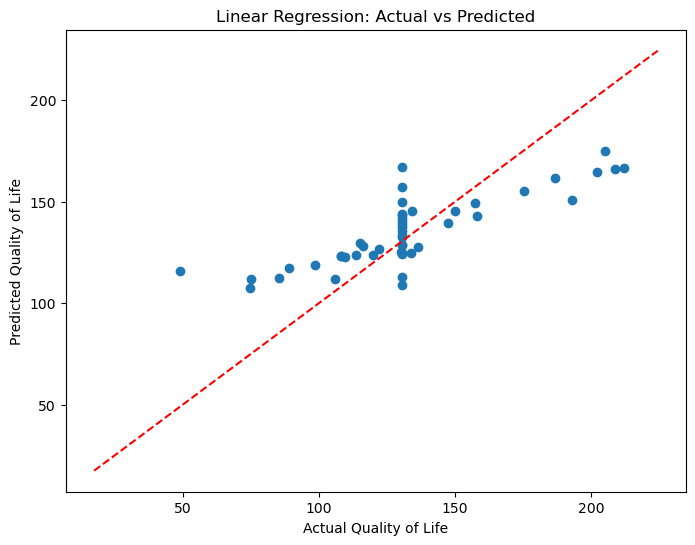

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Quality of Life")

plt.ylabel("Predicted Quality of Life")

plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--"
)

plt.show()

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [60]:
print("Random Forest Performance")
print("-"*40)

print("R² Score:", round(r2_score(y_test, y_pred_rf),3))

print("MAE:", round(mean_absolute_error(y_test, y_pred_rf),3))

print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)),3))

Random Forest Performance
----------------------------------------
R² Score: 0.816
MAE: 9.798
RMSE: 14.513


In [61]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

comparison

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.568605,17.297299,22.230376
1,Random Forest,0.816130,9.797988,14.513261


In [62]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Purchasing Power Value,0.424161
3,Climate Value,0.279888
7,Pollution Value,0.118603
5,Property Price to Income Value,0.054845
6,Traffic Commute Time Value,0.040828
2,Health Care Value,0.032040
4,Cost of Living Value,0.029949
1,Safety Value,0.019685


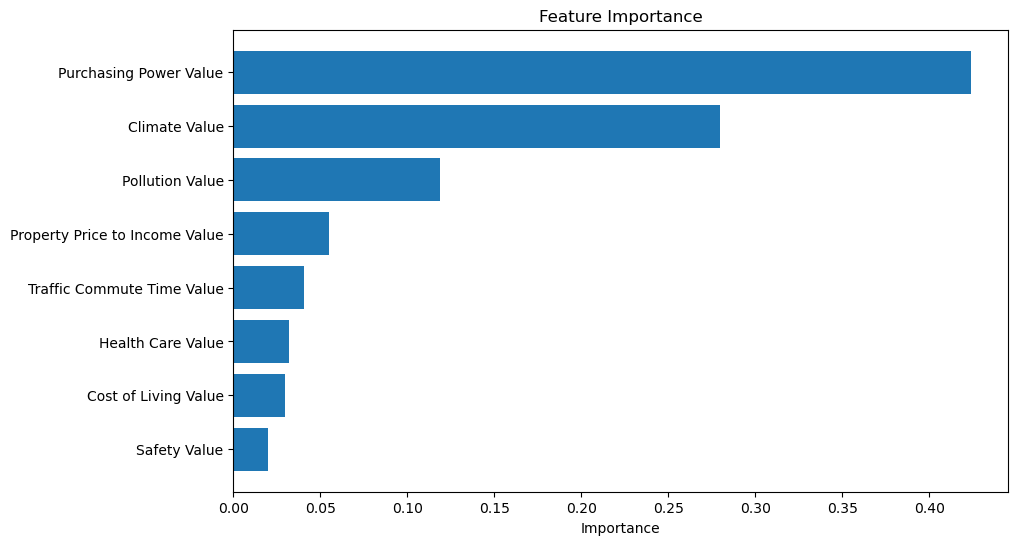

In [63]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

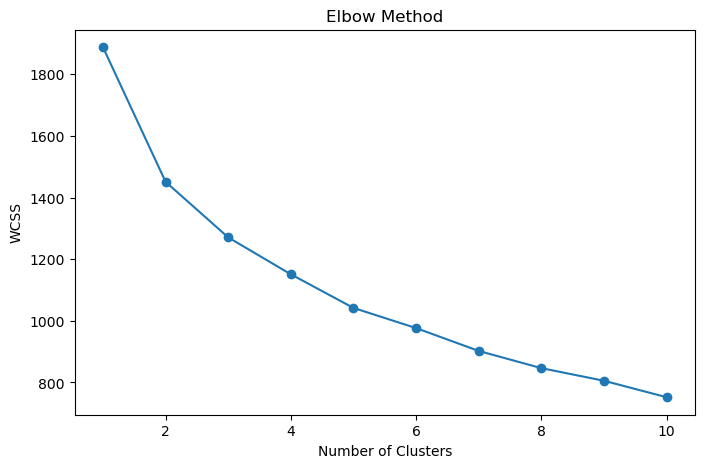

In [65]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [66]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category,Cluster
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,80.60,Unknown,21.08,Very Low,7.80,Low,56.17,Very High,84.44,Very High,130.42,Unknown,1
1,Aland Islands,125.01,Very High,71.81,High,79.72,High,80.60,Unknown,53.44,Low,5.33,Low,19.05,Very Low,18.05,Very Low,130.42,Unknown,0
2,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,Low,14.88,High,36.74,Moderate,77.25,High,104.16,Low,2
3,Alderney,52.70,Unknown,83.79,Very High,100.00,Very High,80.60,Unknown,41.72,Unknown,12.41,Unknown,5.00,Very Low,1.72,Very Low,130.42,Unknown,0
4,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,Very Low,21.70,Very High,45.09,High,63.87,High,98.83,Very Low,1


In [67]:
cluster_summary = df.groupby("Cluster")[
    [
        "Quality of Life Value",
        "Purchasing Power Value",
        "Safety Value",
        "Health Care Value",
        "Pollution Value"
    ]
].mean()

cluster_summary

,Quality of Life Value,Purchasing Power Value,Safety Value,Health Care Value,Pollution Value
Cluster,,,,,
0,155.042561,107.007439,69.243171,70.155244,38.466585
1,114.289375,42.983542,43.908750,56.474583,71.603750
2,123.204078,45.039417,50.875146,50.370583,65.074951
3,130.420000,20.873333,42.853333,45.740000,60.480000


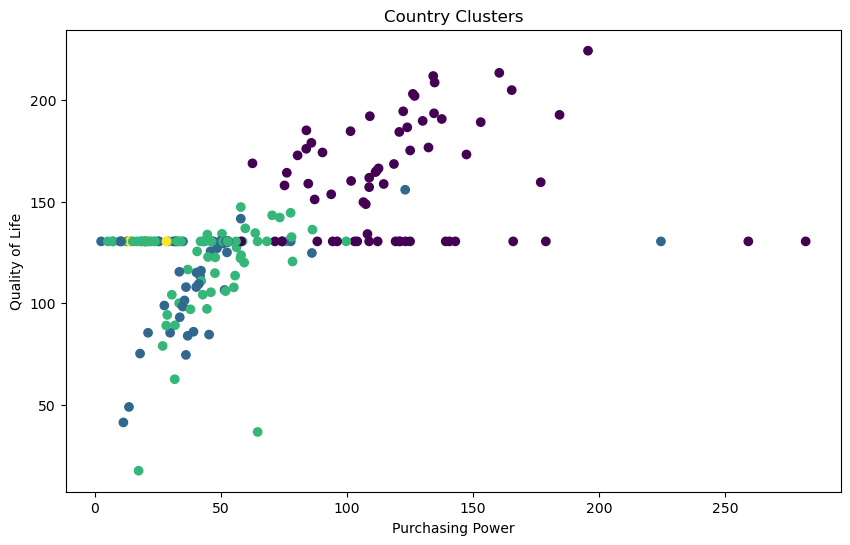

In [68]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Purchasing Power Value"],
    df["Quality of Life Value"],
    c=df["Cluster"]
)

plt.xlabel("Purchasing Power")

plt.ylabel("Quality of Life")

plt.title("Country Clusters")

plt.show()

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [70]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [71]:
rf = RandomForestRegressor(random_state=42)

In [72]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [73]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [74]:
print("Best Cross-Validation R²:")
print(grid_search.best_score_)

Best Cross-Validation R²:
0.6423344769565544


In [75]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
pred_best = best_rf.predict(X_test)

In [77]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

print("Optimized Random Forest")
print("-" * 40)

print("R²:", round(r2_score(y_test, pred_best), 3))
print("MAE:", round(mean_absolute_error(y_test, pred_best), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_best)), 3))

Optimized Random Forest
----------------------------------------
R²: 0.733
MAE: 11.858
RMSE: 17.505


In [78]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "R²": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, pred_best)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, pred_best)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_best))
    ]
})

comparison

,Model,R²,MAE,RMSE
0,Linear Regression,0.568605,17.297299,22.230376
1,Random Forest,0.816130,9.797988,14.513261
2,Optimized Random Forest,0.732515,11.857763,17.504876


In [79]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [80]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [81]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

In [82]:
print("Cross-Validation R² Scores:")
print(cv_scores)

Cross-Validation R² Scores:
[0.23653859 0.74817282 0.70738544 0.74274992 0.70804096]


In [83]:
print("Average R²:", np.mean(cv_scores))

Average R²: 0.6285775441847212


In [84]:
print("Standard Deviation:", np.std(cv_scores))

Standard Deviation: 0.19675264658726158


In [85]:
print("="*50)
print("Random Forest Cross-Validation")
print("="*50)

print("Fold Scores:")
print(cv_scores)

print()

print("Average R²:", round(np.mean(cv_scores),3))

print("Standard Deviation:", round(np.std(cv_scores),3))

Random Forest Cross-Validation
Fold Scores:
[0.23653859 0.74817282 0.70738544 0.74274992 0.70804096]

Average R²: 0.629
Standard Deviation: 0.197


In [86]:
!pip install xgboost

In [88]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [89]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

In [90]:
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [91]:
y_pred_xgb = xgb.predict(X_test)

In [92]:
print("="*50)
print("XGBoost Performance")
print("="*50)

print("R²:", round(r2_score(y_test, y_pred_xgb),3))

print("MAE:", round(mean_absolute_error(y_test, y_pred_xgb),3))

print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)),3))

XGBoost Performance
R²: 0.791
MAE: 8.887
RMSE: 15.461


In [93]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Purchasing Power Value,0.348216
3,Climate Value,0.291427
7,Pollution Value,0.156283
5,Property Price to Income Value,0.084051
6,Traffic Commute Time Value,0.050926
2,Health Care Value,0.033488
1,Safety Value,0.023616
4,Cost of Living Value,0.011992


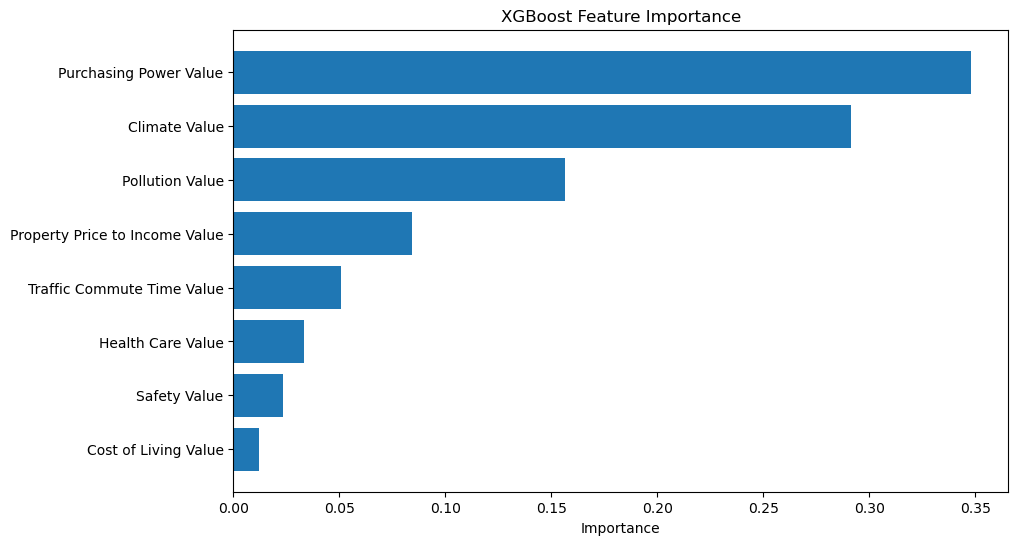

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [95]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("="*50)
print("XGBoost Cross Validation")
print("="*50)

print("Fold Scores:")

print(cv_scores)

print()

print("Average R²:", round(np.mean(cv_scores),3))

print("Standard Deviation:", round(np.std(cv_scores),3))

XGBoost Cross Validation
Fold Scores:
[0.16095653 0.8195284  0.81712638 0.75663234 0.74435331]

Average R²: 0.66
Standard Deviation: 0.251


In [96]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R²":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_xgb)
    ],

    "MAE":[
        mean_absolute_error(y_test,y_pred_lr),
        mean_absolute_error(y_test,y_pred_rf),
        mean_absolute_error(y_test,y_pred_xgb)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,y_pred_lr)),
        np.sqrt(mean_squared_error(y_test,y_pred_rf)),
        np.sqrt(mean_squared_error(y_test,y_pred_xgb))
    ]

})

comparison

,Model,R²,MAE,RMSE
0,Linear Regression,0.568605,17.297299,22.230376
1,Random Forest,0.816130,9.797988,14.513261
2,XGBoost,0.791324,8.887130,15.461274


In [97]:
!pip install shap

In [98]:
import shap
import matplotlib.pyplot as plt

In [100]:
explainer = shap.TreeExplainer(best_rf)

In [101]:
shap_values = explainer.shap_values(X)

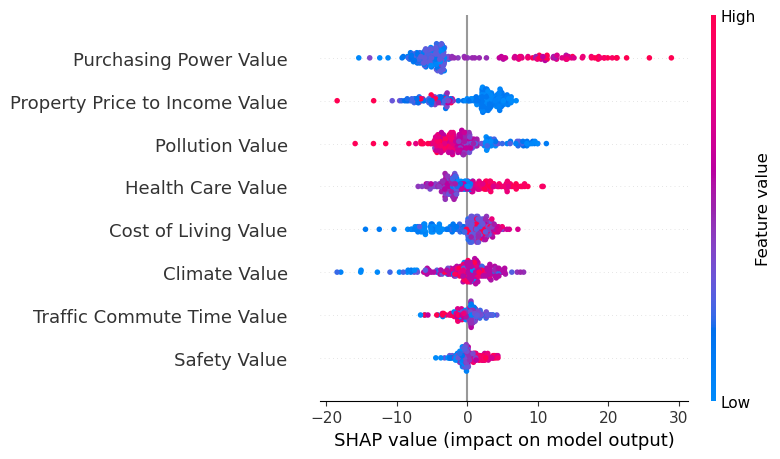

In [102]:
shap.summary_plot(
    shap_values,
    X
)

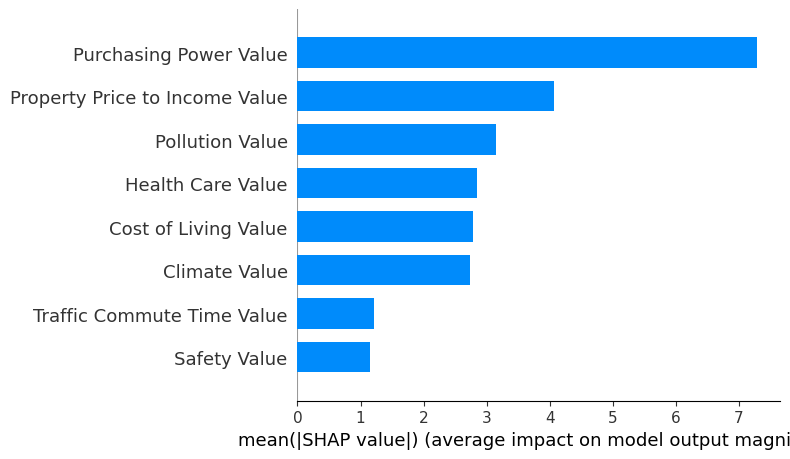

In [103]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

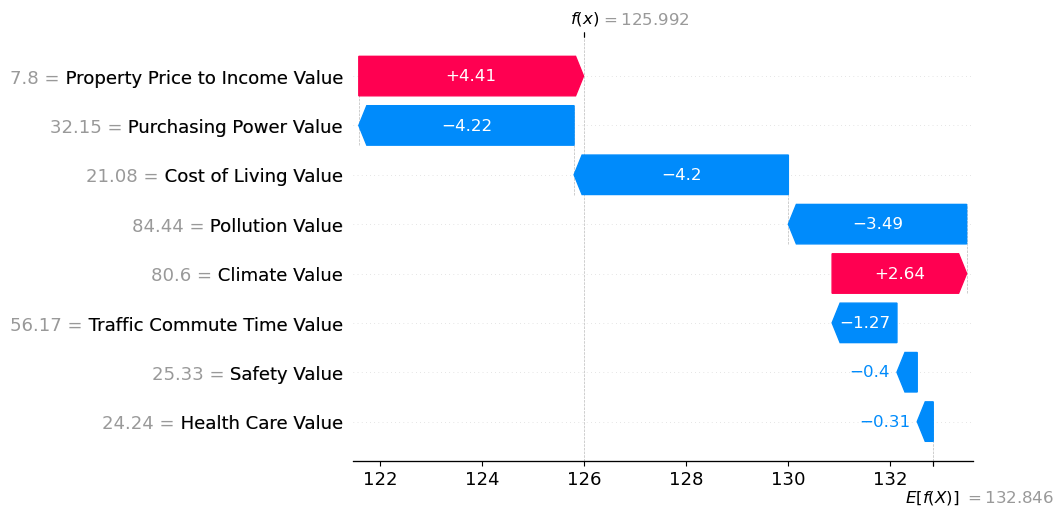

In [104]:
sample = 0

explanation = shap.Explanation(
    values=shap_values[sample],
    base_values=explainer.expected_value,
    data=X.iloc[sample],
    feature_names=X.columns
)

shap.plots.waterfall(explanation)

In [105]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X.iloc[0]
)

In [106]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

In [107]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [108]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

In [109]:
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-3.571416,-0.781702
1,2.907801,0.336642
2,-1.088838,0.034045
3,3.497235,0.706559
4,-1.534240,0.172988


In [110]:
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.32681474 0.14644107]


In [111]:
print("Total Variance Explained:")

print(sum(pca.explained_variance_ratio_))

Total Variance Explained:
0.47325581093600355


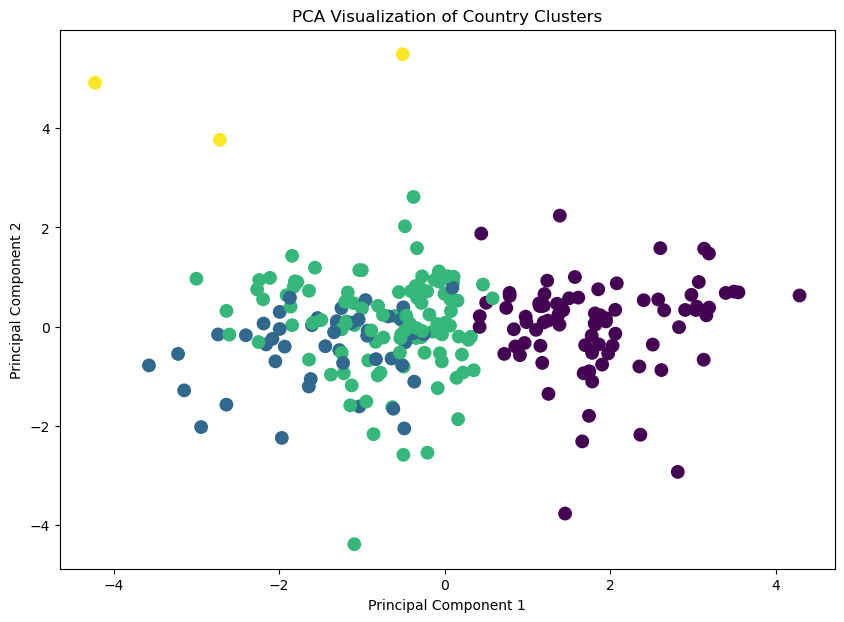

In [112]:
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=df["Cluster"],
    s=80
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Visualization of Country Clusters")

plt.show()

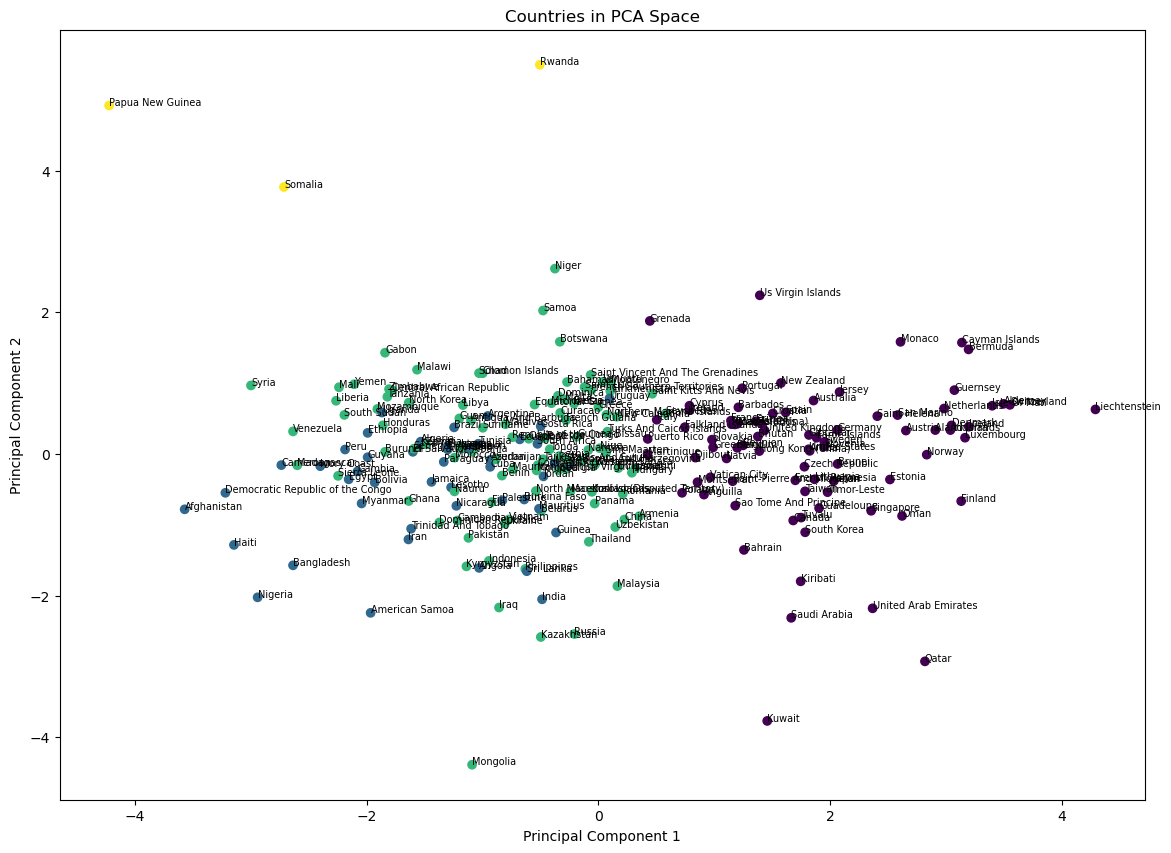

In [113]:
plt.figure(figsize=(14,10))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=df["Cluster"]
)

for i, country in enumerate(df["country"]):
    plt.text(
        pca_df.iloc[i,0],
        pca_df.iloc[i,1],
        country,
        fontsize=7
    )

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Countries in PCA Space")

plt.show()

In [114]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=X.columns
)

loadings

,PC1,PC2
Purchasing Power Value,0.443193,-0.154305
Safety Value,0.468147,-0.129114
Health Care Value,0.424879,-0.170408
Climate Value,-0.071477,0.591513
Cost of Living Value,0.318659,0.350497
Property Price to Income Value,-0.170687,0.496926
Traffic Commute Time Value,-0.254649,-0.370404
Pollution Value,-0.450846,-0.271313


In [123]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
import joblib as jb

In [125]:
jb.dump(rf, "quality_of_life_model.pkl")

['quality_of_life_model.pkl']

In [126]:
loaded_model = joblib.load("quality_of_life_model.pkl")

In [127]:
predictions = loaded_model.predict(X_test)

print(predictions[:10])

[116.70995 164.81245 130.3705  130.31635 149.8647  104.86495 129.6003
 150.329   179.84075 109.0667 ]


In [129]:
from sklearn.metrics import r2_score

predictions = loaded_model.predict(X_test)

print("R² Score:", round(r2_score(y_test, predictions), 3))

R² Score: 0.816


In [130]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [131]:
loaded_scaler = joblib.load("scaler.pkl")